In [217]:
%%capture
import numpy as np
import matplotlib.pyplot as plt
from histpy import Histogram
%matplotlib inline
import healpy as hp

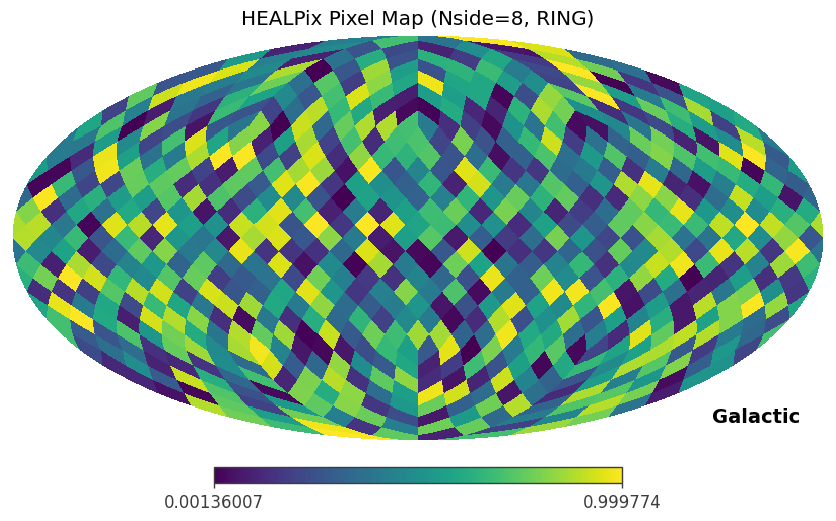

In [218]:
# Set HEALPix parameters
nside = 8  # Resolution parameter
npix = hp.nside2npix(nside)  # Compute the number of pixels (should be 768)
assert npix == 768, "Npix does not match the expected value!"

# Create a pixel map with random values (for demonstration)
pixel_map = np.random.rand(npix)  # Assign a random value to each pixel

# Plot the HEALPix map in the RING scheme
hp.mollview(pixel_map, title="HEALPix Pixel Map (Nside=8, RING)", coord=['G'], nest=False)
plt.show()

Find the pixel in the location of the source

In [233]:
# HEALPix parameters
nside = 8  # Given resolution
npix = hp.nside2npix(nside)  # Total pixels (should be 768)

# Define Galactic coordinate box (in degrees)
# Locatation of NGC4151 in galactic coordinates
l_min, l_max = 155.077 - 1, 155.077 + 1
b_min, b_max = 75.063 - 1, 75.063 + 1

# Convert Galactic (l, b) to HEALPix theta (colatitude) and phi (longitude)
l_vals = np.linspace(l_min, l_max, 10)  # Sample points within the range
b_vals = np.linspace(b_min, b_max, 10)

# Convert (l, b) to (theta, phi)
pixels = set()
for l in l_vals:
    for b in b_vals:
        theta = np.radians(90 - b)  # Convert latitude to colatitude
        phi = np.radians(l)         # Longitude remains unchanged
        pix = hp.ang2pix(nside, theta, phi, nest=False)  # Get pixel index
        pixels.add(pix)  # Store unique pixels

# Output the pixel numbers
pixel_list = sorted(pixels)
print("Pixels in the given range:", pixel_list)

Pixels in the given range: [7]


Slicing Method Attempt

In [203]:
NGC4151ec200 = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/NGC_4151_ec200_COSI_sourceInj_correctFlux.hdf5")
background = Histogram.open("/Users/parshad/Software/cosipyFiles/bkg_binned_data.hdf5")
# background = Histogram.open("/Users/parshad/Software/AGN_Coronae/SourceInj/total_bg_3months_binned_for_continuum.hdf5")

In [180]:
NGC4151ec200.axes.labels

array(['Em', 'Phi', 'PsiChi'], dtype='<U6')

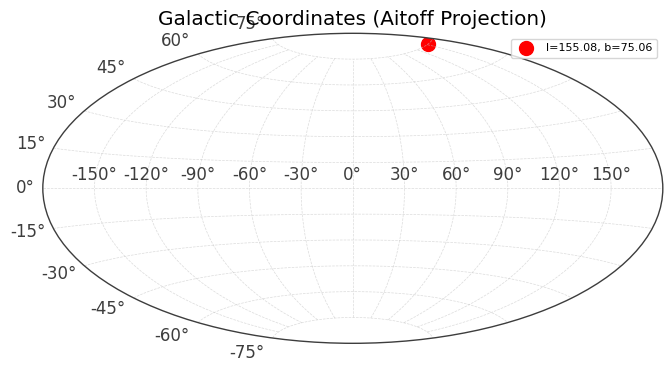

In [176]:
# Convert degrees to radians for projection
l_rad = np.radians(155.08)
b_rad = np.radians(75.06)

# Create an Aitoff projection plot
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="aitoff")

# Plot the point
ax.scatter(l_rad, b_rad, color='red', s=100, label=f"l=155.08, b=75.06")

# Formatting
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
ax.set_title("Galactic Coordinates (Aitoff Projection)")

# Show the plot
plt.show()

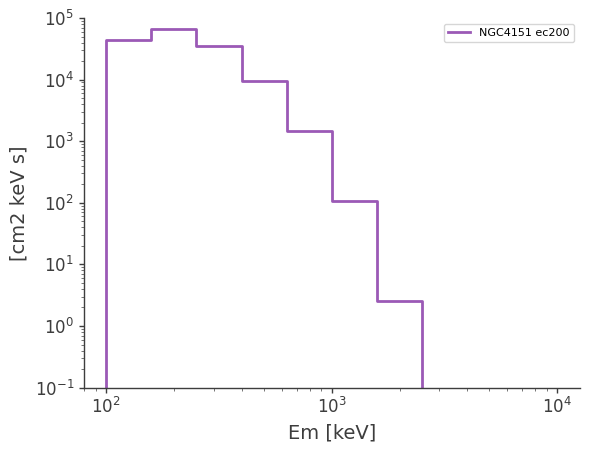

In [181]:
ax,plot = NGC4151ec200.project("Em").plot(label="NGC4151 ec200")
# (background.project("Em")).plot(ax, label="Bakcground")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-1, 1e5)
ax.legend()

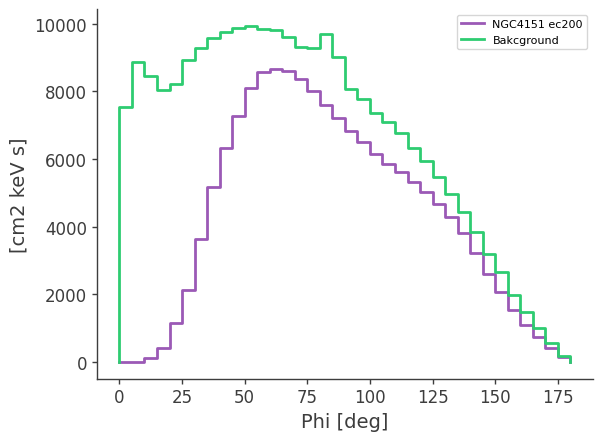

In [182]:
ax,plot = NGC4151ec200.project("Phi").plot(label="NGC4151 ec200")
(background.project("Phi")*5e-3).plot(ax, label="Bakcground")
ax.legend()

Text(0.5, 1.0, 'PsiChi Binning (counts); Background')

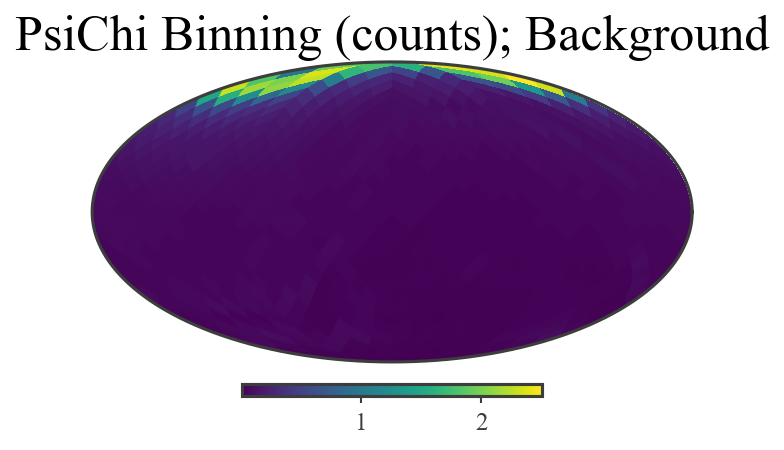

In [ ]:
# plot, ax = NGC4151ec200.slice[:, 10, :].project('PsiChi').plot(ax_kw = {'coord':'G'})
# plot, ax = NGC4151ec200.slice[:, 2, :].project('PsiChi').plot(ax_kw = {'coord':'G'})
plot, ax = NGC4151ec200.project('PsiChi').plot(ax_kw = {'coord':'G'})
ax.get_figure().set_figwidth(4)
ax.get_figure().set_figheight(3)
plt.title("PsiChi Binning (counts); NGC4151ec200")

plot, ax = background.slice[:, :, :, 7].project('PsiChi').plot(ax_kw = {'coord':'G'})
ax.get_figure().set_figwidth(4)
ax.get_figure().set_figheight(3)
plt.title("PsiChi Binning (counts); Background")


PsiChi slicing

In [ ]:
# 0 - 768 binning for PsiChi
# bins = NGC4151ec200.axes["PsiChi"].edges
# print(f"Bins range: {bins[0]}, {bins[1]}")

bins = np.arange(0, 768, 1)
# ax,plot = NGC4151ec200.project("Em").plot(label="Original")
flux_total = np.sum(NGC4151ec200.project("Em")).value
flux_max = np.sum(NGC4151ec200.slice[:, :, 0].project("Em")).value
print(flux_max)

for i in bins:
    flux = np.sum(NGC4151ec200.slice[:, :, i].project("Em")).value
    if flux > flux_max:
        flux_max = flux
        index_max = i
    # NGC4151ec200.slice[:, :, i].project("Em").plot(ax, label=f"Sliced at {i} bin")

print(f"Max index = {index_max} with flux = {flux_max}; total flux of NGC4151: {flux_total}")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()

Bins range: 180.0 deg, 0.0 deg


PsiChi slicing by range (5, 10 etc ...)

In [199]:
# 0 - 768 binning for PsiChi
# bins = NGC4151ec200.axes["PsiChi"].edges
# print(f"Bins range: {bins[0]}, {bins[1]}")
# NGC4151ec200.axes["PsiChi"]
diff = 1
bins = np.arange(0+diff, 768, diff)
# ax,plot = NGC4151ec200.project("Em").plot(label="Original")
flux_total = np.sum(NGC4151ec200.project("Em")).value
flux_max = np.sum(NGC4151ec200.slice[:, 0, 0:diff].project("Em")).value
print(f"Flux at start: {flux_max}")
i_last = 0

for i in bins:
    flux = np.sum(NGC4151ec200.slice[:, 0, i_last:i].project("Em")).value
    if flux > flux_max:
        flux_max = flux
        index_maxS = i_last
        index_max = i
    i_last = i
    # NGC4151ec200.slice[:, :, i].project("Em").plot(ax, label=f"Sliced at {i} bin")

print(f"Max index = {index_maxS}, {index_max} with flux = {flux_max}; total flux of NGC4151: {flux_total}")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()

Flux at start: 0.0002789799808086978
Max index = 7, 8 with flux = 0.0029929059646862676; total flux of NGC4151: 157243.9802846808


PsiChi slicing for background

In [200]:
# ax,plot = background.project("Em").plot(label="Original")
# bins = background.axes["PsiChi"].edges
# bins
# background.axes.labels

flux_total = np.sum(background.project("Em"))
flux_max = np.sum(background.slice[:, :, 0, index_maxS:index_max].project("Em"))

print(f"Index range = {index_maxS}, {index_max} with flux = {flux_max}; total flux of NGC4151: {flux_total}")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()

Index range = 7, 8 with flux = 1838.0; total flux of NGC4151: 48829995.0


Phi slicing

In [155]:
# 0 - 180 deg bining for Phi (every 5 degrees)
bins = NGC4151ec200.axes["Phi"].edges
diff = 6
bins = np.arange(0+diff, len(bins)-1, diff)
# bins = np.arange(0, 180, 5)
# bins
# bins = NGC4151ec200.axes["Phi"][0,:]
# ax,plot = NGC4151ec200.project("Em").plot(label="Original")
flux_total = np.sum(NGC4151ec200.project("Em")).value
flux_max = np.sum(NGC4151ec200.slice[:, 0:diff, :].project("Em")).value
i_last = 0

for i in bins:
    flux = np.sum(NGC4151ec200.slice[:, i_last:i, :].project("Em")).value
    if flux > flux_max:
        flux_max = flux
        index_maxS = i_last
        index_max = i
    i_last = i
    # NGC4151ec200.slice[:, :, i].project("Em").plot(ax, label=f"Sliced at {i} bin")

print(f"Max index = {index_maxS}, {index_max} with flux = {flux_max}; total flux of NGC4151: {flux_total}; fraction of flux: {(flux_max*100)/flux_total}%")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()



Max index = 12, 18 with flux = 48445.0737920731; total flux of NGC4151: 157243.9802846808; fraction of flux: 30.80885748654174%


In [156]:
# ax,plot = background.project("Em").plot(label="Original")
# bins = background.axes["PsiChi"].edges
# bins
# background.axes.labels

flux_total = np.sum(background.project("Em"))
flux_max = np.sum(background.slice[:, :, index_maxS:index_max, :].project("Em"))

print(f"Index range = {index_maxS}, {index_max} with flux = {flux_max}; total flux of NGC4151: {flux_total}; fraction of flux: {(flux_max*100)/flux_total}%")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()

Index range = 12, 18 with flux = 11340108.0; total flux of NGC4151: 48829995.0; fraction of flux: 23.223651773873826%


Phi and PsiChi slicing

In [174]:
# 0 - 180 deg bining for Phi (every 5 degrees)
diff = 5 # 0 - 180
diff_PsiChi = 50 # 0 - 768

bins = NGC4151ec200.axes["Phi"].edges
bins = np.arange(0+diff, len(bins)-1, diff)
bins_PsiChi = NGC4151ec200.axes["PsiChi"].edges
bins_PsiChi = np.arange(0+diff_PsiChi, len(bins_PsiChi)-1, diff_PsiChi)
# bins = np.arange(0, 180, 5)
# bins
# bins = NGC4151ec200.axes["Phi"][0,:]
# ax,plot = NGC4151ec200.project("Em").plot(label="Original")
flux_total = np.sum(NGC4151ec200.project("Em")).value
flux_max = np.sum(NGC4151ec200.slice[:, 0:diff, 0:diff_PsiChi].project("Em")).value
print(f"Max flux at 0, 0: {flux_max}")
i_last = 0
j_last = 0

for i in bins:
    j_last = 0
    for j in bins_PsiChi: 
        # print(f"i: {i}, j: {j}, i_last: {i_last}, j_last: {j_last}")
        flux = np.sum(NGC4151ec200.slice[:, i_last:i, j_last:j].project("Em")).value
        if flux > flux_max:
            flux_max = flux
            index_max_Phi = i
            index_max_PsiChi = j
        j_last = j
    i_last = i
        # NGC4151ec200.slice[:, :, i].project("Em").plot(ax, label=f"Sliced at {i} bin")

print(f"Max index Phi range = {index_max_Phi-diff}, {index_max_Phi} \nMax index with PsiChi range: {index_max_PsiChi-diff_PsiChi} {index_max_PsiChi} \nFlux = {flux_max} \nTotal flux of NGC4151: {flux_total} \nFraction of flux: {(flux_max*100)/flux_total}%")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()



Max flux at 0, 0: 702.318238635795
Max index Phi range = 10, 15 
Max index with PsiChi range: 150 200 
Flux = 5886.640912103535 
Total flux of NGC4151: 157243.9802846808 
Fraction of flux: 3.743635146761183%


In [177]:
# ax,plot = background.project("Em").plot(label="Original")
# bins = background.axes["PsiChi"].edges
# bins
# background.axes.labels

flux_total = np.sum(background.project("Em"))
flux_max = np.sum(background.slice[:, :, index_max_Phi-diff:index_max_Phi, index_max_PsiChi-diff_PsiChi:index_max_PsiChi].project("Em"))

print(f"Index range = {index_maxS}, {index_max} \nFlux = {flux_max} \nTotal flux of NGC4151: {flux_total} \nfraction of flux: {(flux_max*100)/flux_total}%")
# ax.set_title("NGC4151 w/ 200 keV cutoff")
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.legend()

Index range = 12, 18 
Flux = 651585.0 
Total flux of NGC4151: 48829995.0 
fraction of flux: 1.334394975874972%


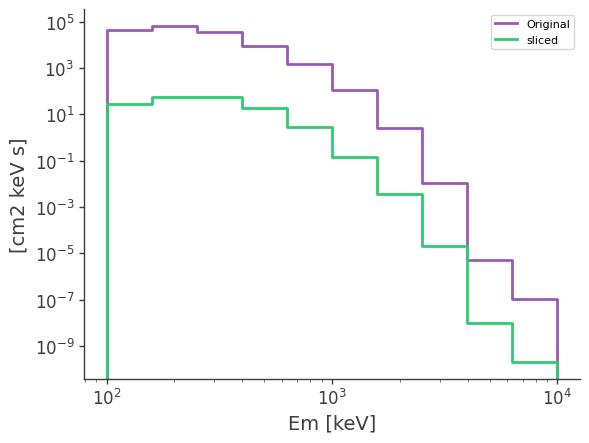

In [ ]:
ax,plot = NGC4151ec200.project("Em").plot(label="Original")
NGC4151ec200.slice[:, :, 4].project("Em").plot(ax, label="sliced")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()

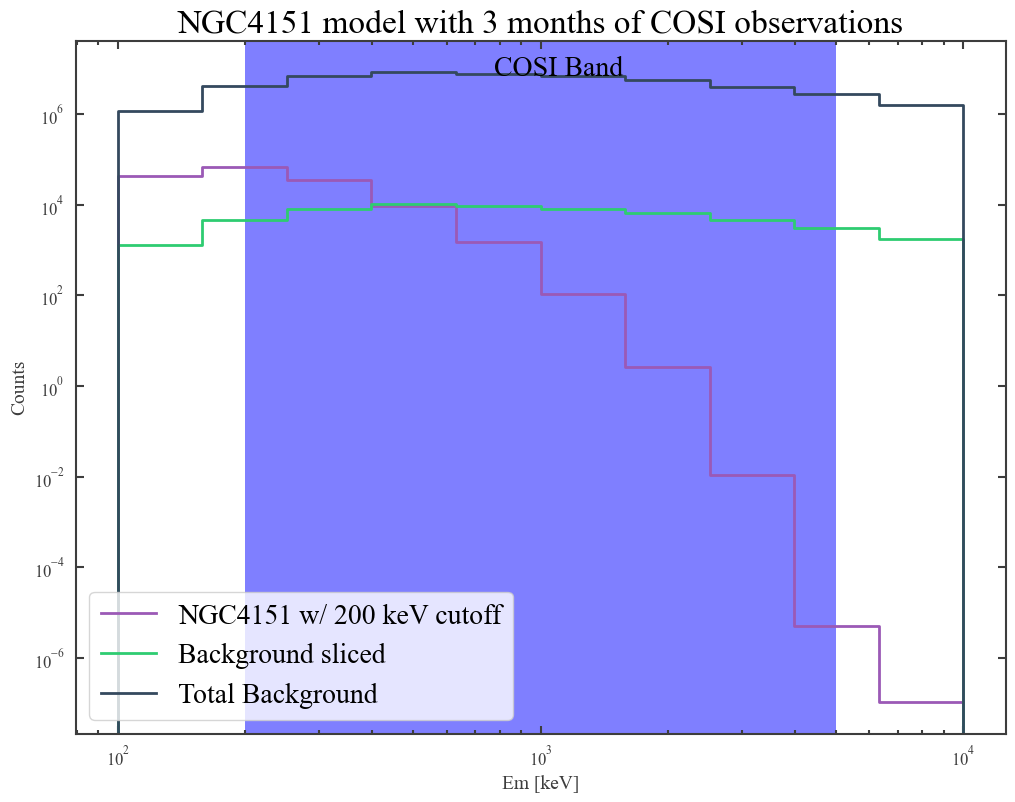

In [236]:
plt.rcParams['agg.path.chunksize'] = 10000

plt.rcParams.update({'font.size': 20})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['axes.linewidth'] = 1.5

plot, ax = plt.subplots(figsize=(12, 9))

NGC4151ec200.project("Em").draw(ax, label="NGC4151 w/ 200 keV cutoff")
background.slice[:, :, :, 7].project("Em").draw(ax, label="Background sliced")
background.project("Em").draw(ax, label="Total Background")

ax.xaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', top='on', pad=8)
ax.xaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', top='on', pad=8)
ax.yaxis.set_tick_params(which='major', size=6, width=1.5, direction='in', right='on', pad=8)
ax.yaxis.set_tick_params(which='minor', size=3, width=1.5, direction='in', right='on', pad=8)

ax.spines['right'].set_visible(True)
ax.spines['top'].set_visible(True)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=20,  loc='lower left')
ax.set_ylabel("Counts")
# ax.set_xlim(1e2, 5e3)
# ax.set_ylim(1e0, 1e9)
ax.axvspan(200, 5000, facecolor ='b', alpha = 0.5) 
ax.text(0.45, 0.95,'COSI Band', transform=ax.transAxes)
ax.set_title("NGC4151 model with 3 months of COSI observations")
# ax.set_title("Crab model with 3 months of COSI observations")
plt.show()